In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown


In [2]:
# Data path
base_path = Path('C:/Users/User/OneDrive/Desktop/UN')
data_path = Path('C:/Users/User/OneDrive/Desktop/UN/Data')

data_files_dict = {'index_1030' : ['index_1030 Gender Development Index.xlsx', '2025_metadata_Gender Development Index 2025.xlsx'],
                   'index_9' : ['index_9 EGDI.xlsx', '20251102_metadata_E-Government Development Index_2024.xlsx', 'raw_EGDI_2024.xlsx'],
                   'index_1032': ['20260710_historical data_index_1032_SDG 2026.xlsx', '20260710_metadata_Sustainable_Development_Index_2026.xlsx', 'raw_SDG_2026.xlsx'],

                    # Somalia indices
                   'index_12' : ['index_12 E-participation Index.xlsx', '', 'raw_EPI_2024.xlsx'],
                   'index_1049' : ['index_1049.xlsx', '', 'raw_IIAG_2024.xlsx'],
                   'index_1037' : ['index_1037.xlsx', '', 'raw_GOVTECH_2022.xlsx'],
                   'index_1022': ['index_1022 Women Peace and security Index.xlsx','','raw_WPS_2025.xlsx'],
                   # Somalia second batch
                   'index_1050': ['index_1050 Global Hunger.xlsx','','raw_GHI.xlsx'],
                   'index_5': ['index_5 ICT Developement Index.xlsx','','raw_ITU_2024.xlsx'],
                   'index_1036': ['20262205_historical data_index_1036_WPF_2026.xlsx','','raw_WPF_2026.xlsx'],

                   # Third
                   'index_1027': ['index_1027 Human Development Index.xlsx','','raw_HDI.xlsx'],
                   'index_1030': ['index_1030 Gender Development Index.xlsx','','raw_GDI_2024.xlsx'],
                   'index_1031': ['index_1031 Planetary adjusted HDI.xlsx','','raw_PPHDI.xlsx'],
                   'index_1035': ['20260303_Historical data _WBL2.0_2026.xlsx','','raw_WBL2.0_2026.xlsx'],
                   # None,
                   'index_1026': ['index_1026 Open data Policies.xlsx','','raw_ODP_2022.xlsx'],
                   'index_1053': ['20260721_historical data_index_1053_BTI2026.xlsx','','raw_BTI_2026.xlsx'],
                   'index_1021': ['index_1021.xlsx','','raw_WBL 1.0.xlsx'],
                   'index_1052': ['20260717_historical data_index_1052_WPJ2026.xlsx','','raw_WJP_2025.xlsx'],
                   'index_1034': ['index_1034.xlsx','','raw_EnviPI_2026.xlsx'],
            
                  }

index_name = 'index_9'
index_data_files = data_files_dict[index_name]
index_historical_kpi_data_path = Path(data_path) / 'Historical' / index_data_files[0]
# Read raw data
historical_kpi_data_raw = pd.read_excel(index_historical_kpi_data_path)

# Reference Data
escwa_members = ['DZA','BHR','COM','DJI','EGY','IRQ','JOR','KWT','LBN','LBY','MRT',
                 'MAR','OMN','PSE','QAT','SAU','SOM','SDN','SYR','TUN','ARE','YEM']

In [3]:


def process_historical_kpi_data(historical_kpi_data_raw, escwa_members=None, filter_to_escwa=False):
    """
    Reformat and filter raw historical KPI data into a long-format DataFrame.

    Parameters
    ----------
    historical_kpi_data_raw : pd.DataFrame
        Raw historical KPI data (wide format), as loaded from source.
    escwa_members : list-like, optional
        List of ISO codes to filter to, if filter_to_escwa is True.
    filter_to_escwa : bool, default False
        Whether to filter the long-format data to escwa_members.

    Returns
    -------
    historical_kpi_data_long : pd.DataFrame
        Long-format historical KPI data, cleaned and type-cast.
    """
    # Index data minor reformatting and filtering
    historical_kpi_data = historical_kpi_data_raw.copy()
    historical_kpi_data = historical_kpi_data.rename(columns={
        'Unnamed: 0': 'KPI ID',
        'Unnamed: 1': 'Series Name',
        'Unnamed: 2': 'year_historical_automated',
        'year': 'year_historical_automated',
        'Series name': 'Series Name',
        'KeyID': 'KPI ID'
    })
    historical_kpi_data = historical_kpi_data.iloc[1:]

    # Values to change, match simulator values
    replacement_dict = {
        'Mean years of schooling': 'Mean Year of Schooling',
        'Expected years of schooling': 'Expected Year of Schooling'
    }
    historical_kpi_data['Series Name'] = historical_kpi_data['Series Name'].replace(replacement_dict)

    # Long format
    historical_kpi_data_long = historical_kpi_data.melt(
        id_vars=['KPI ID', 'Series Name', 'year_historical_automated'],
        var_name='ISO',
        value_name='data_historical_automated'
    )

    if filter_to_escwa and escwa_members is not None:
        historical_kpi_data_long = historical_kpi_data_long[
            historical_kpi_data_long['ISO'].isin(escwa_members)
        ]

    # Format values for consistency
    historical_kpi_data_long['data_historical_automated'] = pd.to_numeric(
        historical_kpi_data_long['data_historical_automated'], errors='coerce'
    ).astype('Float64')
    historical_kpi_data_long['KPI ID'] = historical_kpi_data_long['KPI ID'].astype(str).str.strip()
    historical_kpi_data_long['year_historical_automated'] = historical_kpi_data_long['year_historical_automated'].astype('Int64')

    return historical_kpi_data_long


historical_kpi_data_long = process_historical_kpi_data(historical_kpi_data_raw, 
                                                       escwa_members=escwa_members, 
                                                       filter_to_escwa=True)

In [4]:
# 1. row count per group, summed, should equal len(df)
group_sizes = historical_kpi_data_long.groupby(["KPI ID", "ISO"], dropna=False).size()
print("sum of group sizes:", group_sizes.sum(), "vs df:", len(historical_kpi_data_long))

# 2. row count actually appended to out_frames inside the function
#    (temporarily add this print inside detect_outliers_by_series, right after
#    out_frames.append(g), or just check before the final .loc reindex)

sum of group sizes: 6216 vs df: 6216


In [73]:

"""
Per-series outlier detection for historical KPI data.

Change vs. previous version: the trend-fitting stage now records *how* each
series was fitted, so logistic-fit groups and smoother-fit groups can be
treated as separate populations downstream.

New columns:
    trend_method            'logistic' | 'rolling_median' | 'median'
    trend_fallback_reason   why the logistic fit was not used (NA if it was)
    logistic_r2             R^2 of the logistic candidate, recorded even when
                            it was rejected for falling below r2_threshold
"""

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------------
# 1. Trend-fitting helpers
# ---------------------------------------------------------------------------
def logistic(t, L, k, t0, b):
    return b + L / (1 + np.exp(-k * (t - t0)))


def modified_zscore(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad == 0:
        mad = np.mean(np.abs(x - med))
    if mad == 0:
        return np.zeros_like(x), 0.0
    z = 0.6745 * (x - med) / mad
    return z, mad


def robust_logistic_fit(t, y):
    """Fit logistic curve; one round of MAD-based downweighting, refit.
    Returns fitted values over t, or None if fit fails."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    L0 = max(y.max() - y.min(), 1e-3)
    b0 = y.min()
    t0_0 = t[np.argmin(np.abs(y - (y.min() + y.max()) / 2))]
    k0 = 4.0 / (t.max() - t.min() + 1e-6)
    p0 = [L0, k0, t0_0, b0]
    bounds = (
        [0, -5, t.min() - 30, -np.inf],
        [L0 * 5 + 1e-6, 5, t.max() + 30, np.inf],
    )
    try:
        popt, _ = curve_fit(logistic, t, y, p0=p0, bounds=bounds, maxfev=20000)
    except Exception:
        return None

    fitted = logistic(t, *popt)
    resid = y - fitted
    z, mad = modified_zscore(resid)
    keep = np.abs(z) <= 3.0
    if keep.sum() >= 5 and keep.sum() < len(t):
        try:
            popt2, _ = curve_fit(logistic, t[keep], y[keep], p0=popt,
                                 bounds=bounds, maxfev=20000)
            fitted = logistic(t, *popt2)
        except Exception:
            pass
    return fitted


def diff_outlier_flags(years, values):
    """Flag abrupt jumps/drops in YoY change, plus a monotonicity check
    when the series is overwhelmingly non-decreasing."""
    n = len(values)
    flags = np.zeros(n, dtype=bool)
    if n < 3:
        return flags
    diffs = np.diff(values)
    year_gaps = np.diff(years)
    rate = diffs / year_gaps

    z, mad = modified_zscore(rate)

    val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
    noise_floor = 0.015 * val_range
    material = np.abs(diffs) > noise_floor
    abrupt = (np.abs(z) > 3.5) & material

    frac_nonneg = np.mean(rate >= -1e-9)
    mono_flag = np.zeros(len(rate), dtype=bool)
    if frac_nonneg >= 0.8:
        tol = max(0.02 * val_range, 1e-6)
        mono_flag = rate < -tol

    step_flag = abrupt | mono_flag
    flags[1:] = step_flag
    return flags


# ---------------------------------------------------------------------------
# 2. Detector functions (applied to residuals, per group, below)
# ---------------------------------------------------------------------------
def detect_outliers_iqr_floored(series: pd.Series, multiplier: float = 3.5,
                                value_range: float = None,
                                floor_pct: float = 0.015) -> pd.Series:
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    flagged = (series < lower_bound) | (series > upper_bound)

    if value_range is not None:
        noise_floor = floor_pct * value_range
        material = series.abs() > noise_floor
        flagged = flagged & material

    return flagged


def detect_outliers_modified_zscore_floored(series: pd.Series, threshold: float = 3.5,
                                            value_range: float = None,
                                            floor_pct: float = 0.015) -> pd.Series:
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0 or np.isnan(mad):
        return pd.Series(False, index=series.index)
    modified_z_scores = 0.6745 * (series - median) / mad
    flagged = np.abs(modified_z_scores) > threshold

    if value_range is not None:
        noise_floor = floor_pct * value_range
        material = series.abs() > noise_floor
        flagged = flagged & material

    return flagged


def detect_outliers_isolation_forest(series: pd.Series,
                                     contamination: float = 0.05) -> pd.Series:
    from sklearn.ensemble import IsolationForest
    s_num = pd.to_numeric(series, errors="coerce")
    notna_pos = np.flatnonzero(~s_num.isna())
    if len(notna_pos) < 30:
        return pd.Series(False, index=series.index)
    X = s_num.iloc[notna_pos].to_numpy().reshape(-1, 1)
    iso = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=200,
        max_samples="auto",
    )
    pred = iso.fit_predict(X)  # 1=inlier, -1=outlier
    mask = pd.Series(False, index=series.index)
    mask.iloc[notna_pos] = (pred == -1)
    return mask


# ---------------------------------------------------------------------------
# 3. Main entry point
# ---------------------------------------------------------------------------
NUMERIC_NEW_COLS = [
    "fitted_trend", "trend_r2", "logistic_r2", "resid",
    "outlier_iqr", "outlier_zscore", "outlier_isoforest",
    "outlier_diff", "outlier_total",
]
STRING_NEW_COLS = ["trend_method", "trend_fallback_reason"]


def detect_outliers_by_series(
    df: pd.DataFrame,
    group_cols: list = ["KPI ID", "ISO"],
    year_col: str = "year_historical_automated",
    value_col: str = "data_historical_automated",
    iqr_multiplier: float = 3.5,
    zscore_threshold: float = 3.5,
    isoforest_contamination: float = 0.05,
    rolling_window_years: int = 5,
    r2_threshold: float = 0.85,
    noise_floor_pct: float = 0.015,
    min_points_logistic: int = 8,
    min_points_rolling: int = 5,
) -> pd.DataFrame:
    """
    Detect outliers per (group_cols) time series, e.g. per (KPI ID, ISO).

    Preserves the original dataframe's shape exactly -- rows with missing
    year/value are kept, they just get NaN/NA in the outlier/trend columns.

    Returns a new dataframe with the same rows as `df` plus:
        fitted_trend, trend_r2, logistic_r2, resid,
        trend_method, trend_fallback_reason,
        outlier_iqr, outlier_zscore, outlier_isoforest, outlier_diff,
        outlier_total

    trend_method values
    -------------------
    'logistic'        robust logistic fit accepted (logistic_r2 >= r2_threshold)
    'rolling_median'  centred rolling median over `rolling_window_years`
    'median'          flat median (fewer than min_points_rolling points)

    trend_fallback_reason values (NA when trend_method == 'logistic')
    -----------------------------------------------------------------
    'too_few_points'   n < min_points_logistic, logistic never attempted
    'fit_failed'       curve_fit raised / did not converge
    'low_r2'           logistic converged but fell below r2_threshold
    'constant_series'  zero total variance, R^2 undefined

    Note: trend_r2 is not comparable across methods. For 'rolling_median' and
    'median' it scores a smoother against the data it smoothed, so it is high
    almost by construction. Filter or compare within trend_method groups.
    """
    df = df.reset_index(drop=True).copy()
    df["_orig_row_"] = df.index

    def rolling_median_by_year(t, y, window_years=rolling_window_years):
        t = np.asarray(t, dtype=float)
        y = np.asarray(y, dtype=float)
        out = np.empty(len(y))
        for i, yr in enumerate(t):
            mask = np.abs(t - yr) <= window_years / 2
            out[i] = np.median(y[mask])
        return out

    out_frames = []
    for _keys, g in df.groupby(group_cols, sort=False, dropna=False):
        g = g.sort_values(year_col).copy()
        for c in NUMERIC_NEW_COLS:
            g[c] = np.nan
        for c in STRING_NEW_COLS:
            g[c] = pd.Series(pd.NA, index=g.index, dtype="object")

        valid = g[[year_col, value_col]].notna().all(axis=1)
        n = int(valid.sum())

        if n == 0:
            out_frames.append(g)
            continue

        v_idx = g.index[valid]
        t = pd.to_numeric(g.loc[v_idx, year_col], errors="coerce").to_numpy(dtype=float)
        y = pd.to_numeric(g.loc[v_idx, value_col], errors="coerce").to_numpy(dtype=float)

        val_range = max(np.nanmax(y) - np.nanmin(y), 1e-9)

        # --- trend fitting, with method provenance --------------------------
        fitted = None
        r2 = np.nan
        logistic_r2 = np.nan
        method = None
        reason = None

        if n < min_points_logistic:
            reason = "too_few_points"
        else:
            candidate = robust_logistic_fit(t, y)
            if candidate is None:
                reason = "fit_failed"
            else:
                ss_res = np.sum((y - candidate) ** 2)
                ss_tot = np.sum((y - np.mean(y)) ** 2)
                if ss_tot <= 0:
                    logistic_r2 = np.nan
                    reason = "constant_series"
                else:
                    logistic_r2 = 1 - ss_res / ss_tot
                    if logistic_r2 >= r2_threshold:
                        fitted = candidate
                        r2 = logistic_r2
                        method = "logistic"
                    else:
                        reason = "low_r2"

        if fitted is None:
            if n >= min_points_rolling:
                fitted = rolling_median_by_year(t, y)
                method = "rolling_median"
            else:
                fitted = np.full(n, np.median(y))
                method = "median"
            ss_res = np.sum((y - fitted) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # --- residual-based detectors ---------------------------------------
        resid = pd.Series(y - fitted, index=v_idx, dtype="float64")

        outlier_iqr = (
            detect_outliers_iqr_floored(resid, multiplier=iqr_multiplier,
                                        value_range=val_range,
                                        floor_pct=noise_floor_pct)
            if n >= 4 else pd.Series(False, index=v_idx)
        )
        outlier_zscore = (
            detect_outliers_modified_zscore_floored(resid, threshold=zscore_threshold,
                                                    value_range=val_range,
                                                    floor_pct=noise_floor_pct)
            if n >= 4 else pd.Series(False, index=v_idx)
        )
        outlier_isoforest = detect_outliers_isolation_forest(
            resid, contamination=isoforest_contamination)
        outlier_isoforest = pd.Series(np.asarray(outlier_isoforest).astype(bool),
                                      index=v_idx)
        outlier_diff = pd.Series(np.asarray(diff_outlier_flags(t, y)).astype(bool),
                                 index=v_idx)

        # --- write back -----------------------------------------------------
        g.loc[v_idx, "fitted_trend"] = np.round(fitted, 4)
        g.loc[v_idx, "trend_r2"] = np.round(r2, 4)
        g.loc[v_idx, "logistic_r2"] = np.round(logistic_r2, 4)
        g.loc[v_idx, "resid"] = np.round(resid.values, 4)
        g.loc[v_idx, "trend_method"] = method
        g.loc[v_idx, "trend_fallback_reason"] = reason if reason is not None else pd.NA
        g.loc[v_idx, "outlier_iqr"] = outlier_iqr.astype(int).values
        g.loc[v_idx, "outlier_zscore"] = outlier_zscore.astype(int).values
        g.loc[v_idx, "outlier_isoforest"] = outlier_isoforest.astype(int).values
        g.loc[v_idx, "outlier_diff"] = outlier_diff.astype(int).values
        g.loc[v_idx, "outlier_total"] = (g.loc[v_idx, "outlier_iqr"]
                                         + g.loc[v_idx, "outlier_zscore"]
                                         + g.loc[v_idx, "outlier_isoforest"]
                                         + g.loc[v_idx, "outlier_diff"])
        out_frames.append(g)

    result = pd.concat(out_frames)
    result = (result.sort_values("_orig_row_")
                    .drop(columns="_orig_row_")
                    .reset_index(drop=True))
    result["trend_method"] = result["trend_method"].astype("string")
    result["trend_fallback_reason"] = result["trend_fallback_reason"].astype("string")
    return result


# ---------------------------------------------------------------------------
# 4. Diagnostics
# ---------------------------------------------------------------------------
def trend_method_summary(result: pd.DataFrame,
                         group_cols: list = ["KPI ID", "ISO"]) -> pd.DataFrame:
    """One row per trend_method: how many series used it, and the flag rate
    among the points it produced. Use this to check whether flags are being
    driven by fit method rather than by the data."""
    scored = result[result["trend_method"].notna()]
    per_series = scored.groupby(group_cols, dropna=False).agg(
        trend_method=("trend_method", "first"),
        reason=("trend_fallback_reason", "first"),
        n_points=("resid", "size"),
    )
    counts = per_series.groupby("trend_method", dropna=False).agg(
        n_series=("n_points", "size"),
        median_points=("n_points", "median"),
    )
    rates = scored.groupby("trend_method", dropna=False).agg(
        n_points=("resid", "size"),
        pct_any_flag=("outlier_total", lambda s: 100 * (s > 0).mean()),
        pct_two_plus=("outlier_total", lambda s: 100 * (s >= 2).mean()),
        pct_iqr=("outlier_iqr", lambda s: 100 * s.mean()),
        pct_zscore=("outlier_zscore", lambda s: 100 * s.mean()),
        pct_isoforest=("outlier_isoforest", lambda s: 100 * s.mean()),
        pct_diff=("outlier_diff", lambda s: 100 * s.mean()),
    )
    return counts.join(rates).round(2)


def fallback_reason_summary(result: pd.DataFrame,
                            group_cols: list = ["KPI ID", "ISO"]) -> pd.Series:
    """Count of series by why the logistic fit was not used."""
    scored = result[result["trend_method"].notna()]
    per_series = scored.groupby(group_cols, dropna=False)["trend_fallback_reason"].first()
    return per_series.value_counts(dropna=False)

result = detect_outliers_by_series(historical_kpi_data_long)
assert len(result) == len(historical_kpi_data_long), \
    f"row count mismatch: {len(result)} vs {len(historical_kpi_data_long)}"

result = detect_outliers_by_series(historical_kpi_data_long)
assert len(result) == len(historical_kpi_data_long), \
    f"row count mismatch: {len(result)} vs {len(historical_kpi_data_long)}"

trend_summary = trend_method_summary(result)


In [74]:
trend_summary.to_clipboard()

In [58]:
import matplotlib.pyplot as plt

# build ordered list of (KPI ID, ISO) groups, most anomalous first
group_summary = (
    result.groupby(["KPI ID", "ISO"])["outlier_total"]
    .max()
    .reset_index()
    .dropna(subset=["outlier_total"])
    .sort_values("outlier_total", ascending=False)
)
group_summary = group_summary[group_summary["outlier_total"] > 3].reset_index(drop=True)
groups_list = list(zip(group_summary["KPI ID"], group_summary["ISO"], group_summary["outlier_total"]))


def plot_series_with_outliers(g: pd.DataFrame, title: str = None):
    if len(g) == 0:
        raise ValueError("No rows matched for this group.")
    g = g.sort_values("year_historical_automated")
    outliers = g[g["outlier_total"] >= 1]

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(g["year_historical_automated"], g["data_historical_automated"],
            marker="o", markersize=4, linewidth=1.5, color="#2563eb",
            label="Actual value", zorder=2)
    ax.plot(g["year_historical_automated"], g["fitted_trend"],
            linestyle="--", linewidth=1.5, color="#6b7280",
            label="Fitted trend", zorder=1)
    ax.scatter(outliers["year_historical_automated"], outliers["data_historical_automated"],
               s=(60 + outliers["outlier_total"] * 40), color="#dc2626",
               edgecolor="black", linewidth=0.7, zorder=3,
               label="Outlier (outlier_total ≥ 1)")
    for _, row in outliers.iterrows():
        ax.annotate(f"{int(row['outlier_total'])}",
                    (row["year_historical_automated"], row["data_historical_automated"]),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, color="#dc2626", fontweight="bold")

    ax.set_title(title or f"{g['KPI ID'].iloc[0]} {g['Series Name'].iloc[0]} — {g['ISO'].iloc[0]}")
    ax.set_xlabel("Year")
    ax.set_ylabel(g["Series Name"].iloc[0])
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


_pos = {"i": -1}   # starts before the first item

def next_series():
    """Re-run this cell (or call next_series() again) to advance."""
    _pos["i"] = (_pos["i"] + 1) % len(groups_list)
    kpi, iso, max_ot = groups_list[_pos["i"]]
    print(f"{_pos['i'] + 1} / {len(groups_list)}  —  KPI {kpi} — {iso}  (max outlier_total={int(max_ot)})")
    g = result[(result["KPI ID"] == kpi) & (result["ISO"] == iso)]
    plot_series_with_outliers(g)

def prev_series():
    _pos["i"] = (_pos["i"] - 1) % len(groups_list)
    kpi, iso, max_ot = groups_list[_pos["i"]]
    print(f"{_pos['i'] + 1} / {len(groups_list)}  —  KPI {kpi} — {iso}  (max outlier_total={int(max_ot)})")
    g = result[(result["KPI ID"] == kpi) & (result["ISO"] == iso)]
    plot_series_with_outliers(g)

#next_series()

5 / 13  —  KPI 281 — DZA  (max outlier_total=4)


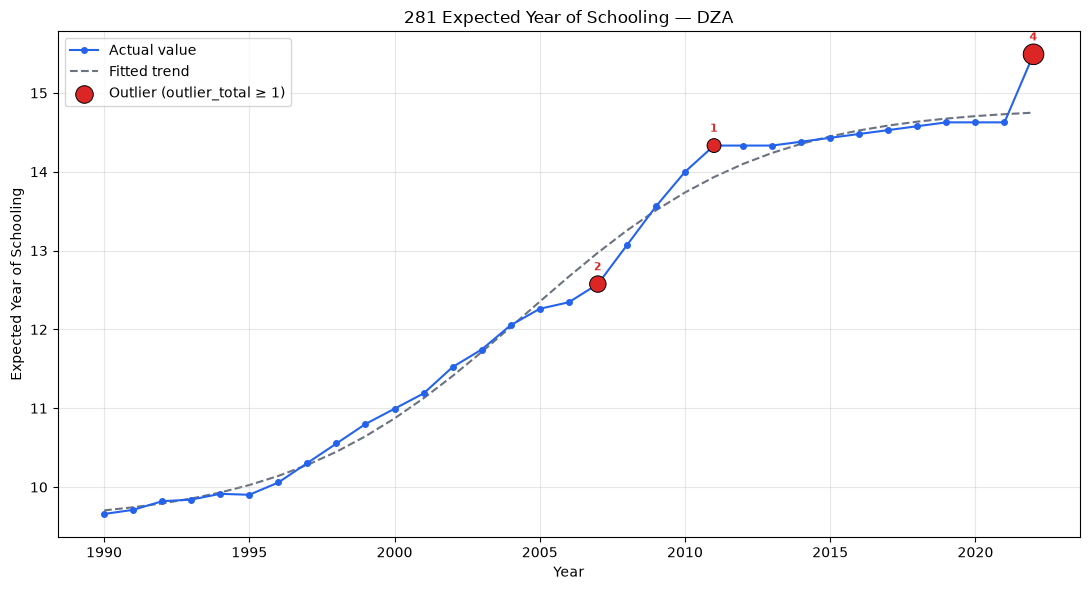

In [78]:
next_series()

In [14]:
ISO = 'MRT'
KPI = '281'

series =result[(result['KPI ID']==KPI) & (result['ISO']==ISO)].copy()
series = series.sort_values('year_historical_automated')
series

,KPI ID,Series Name,year_historical_automated,ISO,data_historical_automated,fitted_trend,trend_r2,resid,outlier_iqr,outlier_zscore,outlier_isoforest,outlier_diff,outlier_total
3063,281,Expected Year of Schooling,1990,MRT,3.71726,3.8571,0.9615,-0.1398,0.0,0.0,0.0,0.0,0.0
3064,281,Expected Year of Schooling,1991,MRT,3.82825,4.1452,0.9615,-0.3169,0.0,0.0,0.0,0.0,0.0
3065,281,Expected Year of Schooling,1992,MRT,4.14691,4.4251,0.9615,-0.2782,0.0,0.0,0.0,0.0,0.0
3066,281,Expected Year of Schooling,1993,MRT,4.64286,4.6968,0.9615,-0.0540,0.0,0.0,0.0,0.0,0.0
3067,281,Expected Year of Schooling,1994,MRT,5.32749,4.9602,0.9615,0.3673,0.0,0.0,0.0,0.0,0.0
3068,281,Expected Year of Schooling,1995,MRT,5.47487,5.2153,0.9615,0.2596,0.0,0.0,0.0,0.0,0.0
3069,281,Expected Year of Schooling,1996,MRT,5.72816,5.4621,0.9615,0.2661,0.0,0.0,0.0,0.0,0.0
3070,281,Expected Year of Schooling,1997,MRT,5.78007,5.7006,0.9615,0.0794,0.0,0.0,0.0,0.0,0.0
3071,281,Expected Year of Schooling,1998,MRT,6.17778,5.9310,0.9615,0.2468,0.0,0.0,0.0,0.0,0.0
3072,281,Expected Year of Schooling,1999,MRT,6.38464,6.1532,0.9615,0.2314,0.0,0.0,0.0,0.0,0.0


In [260]:
ISO = 'KWT'
KPI = '282'

series =result[(result['KPI ID']==KPI) & (result['ISO']==ISO)].copy()
series = series.sort_values('year_historical_automated')

years = pd.to_numeric(series['year_historical_automated'], errors="coerce").to_numpy(dtype=float)
values = pd.to_numeric(series['data_historical_automated'], errors="coerce").to_numpy(dtype=float)

n = len(values)
flags = np.zeros(n, dtype=bool)

diffs = np.diff(values)
year_gaps = np.diff(years)
rate = diffs / year_gaps
z, mad = modified_zscore(rate)

val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
noise_floor = 0.015 * val_range

material = np.abs(diffs) > noise_floor
abrupt = (np.abs(z) > 3.5) & material
frac_nonneg = np.mean(rate >= -1e-9)

C:\Users\User\repos\un\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\User\repos\un\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation fmax which has no identity

In [144]:
val_range = max(np.nanmax(values) - np.nanmin(values), 1e-9)
noise_floor = 0.015 * val_range
abrupt = (np.abs(z) > 3.5) & material


In [151]:
material = np.abs(diffs) > noise_floor

In [154]:
frac_nonneg

np.float64(0.9)

In [ ]:
t = pd.to_numeric(g.loc[v_idx, year_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(g.loc[v_idx, value_col], errors="coerce").to_numpy(dtype=float)

In [ ]:
282 — KWT

In [121]:
series

,KPI ID,Series Name,year_historical_automated,ISO,data_historical_automated,fitted_trend,resid,outlier_iqr,outlier_zscore,outlier_isoforest,outlier_diff,outlier_total
2072,282,Mean Year of Schooling,2022,KWT,7.3,7.4465,-0.1465,0.0,0.0,0.0,0.0,0.0
2073,282,Mean Year of Schooling,1990,KWT,5.5,5.5796,-0.0796,0.0,0.0,0.0,0.0,0.0
2074,282,Mean Year of Schooling,1991,KWT,5.5,5.6115,-0.1115,0.0,0.0,0.0,0.0,0.0
2075,282,Mean Year of Schooling,1992,KWT,5.6,5.6460,-0.0460,0.0,0.0,0.0,0.0,0.0
2076,282,Mean Year of Schooling,1993,KWT,5.7,5.6834,0.0166,0.0,0.0,0.0,0.0,0.0
2077,282,Mean Year of Schooling,1994,KWT,5.7,5.7238,-0.0238,0.0,0.0,0.0,0.0,0.0
2078,282,Mean Year of Schooling,1995,KWT,5.8,5.7672,0.0328,0.0,0.0,0.0,0.0,0.0
2079,282,Mean Year of Schooling,1996,KWT,5.9,5.8137,0.0863,0.0,0.0,0.0,0.0,0.0
2080,282,Mean Year of Schooling,1997,KWT,6.0,5.8634,0.1366,0.0,0.0,0.0,0.0,0.0
2081,282,Mean Year of Schooling,1998,KWT,6.0,5.9162,0.0838,0.0,0.0,0.0,0.0,0.0


In [ ]:
#============================================================
# C) OUTLIER DETECTION (CONSENSUS)
# ============================================================




def detect_outliers_multiple_methods(
    series: pd.Series,
    consensus_threshold: int = 2,
    iqr_multiplier: float = 3.0,
    zscore_threshold: float = 3.5,
    iso_contamination: float = 0.05,
) -> dict:
    """
    Consensus outlier detection using IQR, modified Z-score, and Isolation Forest.

    Thresholds are now explicit parameters rather than hardcoded, so
    frequency-aware contexts (ctx_d / ctx_m / ctx_q) can pass their own values.
    """
    outliers_iqr = detect_outliers_iqr(series, multiplier=iqr_multiplier)
    outliers_z   = detect_outliers_modified_zscore(series, threshold=zscore_threshold)

    n = series.notna().sum()
    # Cap contamination at a reasonable max; also respect the passed value
    contam = min(iso_contamination, 0.05) if n >= 400 else iso_contamination
    outliers_iso = detect_outliers_isolation_forest(series, contamination=contam)

    counts    = outliers_iqr.astype(int) + outliers_z.astype(int) + outliers_iso.astype(int)
    consensus = counts >= consensus_threshold

    return {
        "outliers":  consensus,
        "iqr":       outliers_iqr,
        "zscore":    outliers_z,
        "isoforest": outliers_iso,
        "counts":    counts,
    }


In [ ]:
# Plan
# - find data that has decent amount of availability 15-25 samples very little missing data
# - compute differences
# - m
# Data
# Year Current, Year Previous, current val, previous val, difference